1. Using Isolation Forest
**bold text**

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

In [85]:
df = pd.read_csv('card_transdata.csv')

In [86]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [87]:
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,742312.000000,742311.000000,742311.000000,742311.000000,742311.000000,742311.000000,742311.000000,742311.000000
mean,26.656267,5.019129,1.823650,0.881552,0.350194,0.100942,0.650599,0.087461
std,65.105774,26.219921,2.800209,0.323138,0.477031,0.301251,0.476781,0.282509
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.880597,0.295959,0.474910,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.974453,0.996616,0.997087,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.766510,3.350859,2.097115,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [88]:
df.isnull().sum()

,0
distance_from_home,0
distance_from_last_transaction,1
ratio_to_median_purchase_price,1
repeat_retailer,1
used_chip,1
used_pin_number,1
online_order,1
fraud,1


In [89]:
df.dropna(inplace=True)

In [90]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [91]:
df.corr()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
distance_from_home,1.000000,0.000805,-0.002170,0.143900,-0.000609,-0.000827,-0.001379,0.188070
distance_from_last_transaction,0.000805,1.000000,0.001282,-0.001582,0.001136,-0.000562,-0.000293,0.089639
ratio_to_median_purchase_price,-0.002170,0.001282,1.000000,0.000994,-0.000278,0.000744,0.000097,0.462010
repeat_retailer,0.143900,-0.001582,0.000994,1.000000,-0.001173,0.000571,-0.000053,-0.001506
used_chip,-0.000609,0.001136,-0.000278,-0.001173,1.000000,-0.001538,0.000301,-0.061623
used_pin_number,-0.000827,-0.000562,0.000744,0.000571,-0.001538,1.000000,-0.000416,-0.100521
online_order,-0.001379,-0.000293,0.000097,-0.000053,0.000301,-0.000416,1.000000,0.192439
fraud,0.188070,0.089639,0.462010,-0.001506,-0.061623,-0.100521,0.192439,1.000000


In [92]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [93]:
df = df.drop(columns=['used_pin_number'])

In [94]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,1.0,0.0


In [95]:
print(df["fraud"].value_counts())

print(df["fraud"].value_counts(normalize=True) * 100)

fraud
0.0    677388
1.0     64923
Name: count, dtype: int64
fraud
0.0    91.253935
1.0     8.746065
Name: proportion, dtype: float64


In [96]:
# X_iso = df.drop("fraud", axis=1)
# y_iso = df["fraud"]

In [97]:
# X_train_iso, X_temp_iso, y_train_iso, y_temp_iso = train_test_split(
#     X_iso,
#     y_iso,
#     test_size=0.30,
#     random_state=42,
#     stratify=y
# )

# X_val_iso, X_test_iso, y_val_iso, y_test_iso = train_test_split(
#     X_temp_iso,
#     y_temp_iso,
#     test_size=0.50,
#     random_state=42,
#     stratify=y_temp_iso
# )

In [98]:
# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train_iso)

# X_val_scaled = scaler.transform(X_val_iso)

# X_test_scaled = scaler.transform(X_test_iso)

In [99]:
# model = IsolationForest(
#     n_estimators=200,
#     max_samples=256,
#     contamination="auto",
#     random_state=42,
#     n_jobs=-1
# )

In [100]:
# model.fit(X_train_scaled)

In [101]:
# train_scores = -model.score_samples(X_train_scaled)

# val_scores = -model.score_samples(X_val_scaled)

# test_scores = -model.score_samples(X_test_scaled)

In [102]:
# print("Validation score range:")
# print(val_scores.min(), val_scores.max())

# print("First 10 scores:")
# print(val_scores[:10])

In [103]:
# precision, recall, thresholds = precision_recall_curve(
#     y_val_iso,
#     val_scores
# )

In [104]:
# f1_scores = 2 * (precision * recall) / (
#     precision + recall + 1e-10
# )

In [105]:
# best_index = np.argmax(f1_scores)

# best_threshold = thresholds[best_index]

# print("Best threshold:", best_threshold)
# print("Best F1:", f1_scores[best_index])

In [106]:
# y_val_pred = (
#     val_scores >= best_threshold
# ).astype(int)

In [107]:
# print(classification_report(
#     y_val_iso,
#     y_val_pred
# ))

In [108]:
# y_test_pred = (
#     test_scores >= best_threshold
# ).astype(int)

In [109]:
# print(classification_report(
#     y_test_iso,
#     y_test_pred
# ))

In [110]:
# cm = confusion_matrix(
#     y_test_iso,
#     y_test_pred
# )

# print(cm)

**2. Using LightGBM**

In [111]:
import pandas as pd
import numpy as np

import lightgbm as lgb

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

In [112]:
print(df["fraud"].value_counts())

fraud
0.0    677388
1.0     64923
Name: count, dtype: int64


In [113]:
print(df["fraud"].value_counts(normalize=True) * 100)

fraud
0.0    91.253935
1.0     8.746065
Name: proportion, dtype: float64


In [114]:
X = df.drop("fraud", axis=1)
y = df["fraud"]

In [115]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [116]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("Scale pos weight:", scale_pos_weight)

Negative: 474171
Positive: 45446
Scale pos weight: 10.433723540025525


In [117]:
model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [118]:
model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_val, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50
        )
    ]
)

[LightGBM] [Info] Number of positive: 45446, number of negative: 474171
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052716 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 771
[LightGBM] [Info] Number of data points in the train set: 519617, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.087461 -> initscore=-2.345043
[LightGBM] [Info] Start training from score -2.345043
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[182]	valid_0's auc: 0.995324	valid_0's binary_logloss: 0.0465872


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
               n_jobs=-1, objective='binary', random_state=42,
               scale_pos_weight=np.float64(10.433723540025525), subsample=0.8,
               subsample_freq=1)

In [119]:
y_val_prob = model.predict_proba(X_val)[:, 1]

y_test_prob = model.predict_proba(X_test)[:, 1]

In [124]:
from sklearn.metrics import precision_recall_curve

In [125]:
precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)

In [126]:
f1_scores = (
    2 * precision * recall /
    (precision + recall + 1e-10)
)

In [127]:
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

best_f1 = f1_scores[best_index]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.8624701534304415
Best F1: 0.9424502535591771


In [128]:
y_val_pred = (
    y_val_prob >= best_threshold
).astype(int)

In [129]:
print(classification_report(
    y_val,
    y_val_pred
))

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99    101608
         1.0       0.90      0.99      0.94      9739

    accuracy                           0.99    111347
   macro avg       0.95      0.99      0.97    111347
weighted avg       0.99      0.99      0.99    111347



In [130]:
best_threshold

np.float64(0.8624701534304415)

In [131]:
y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

In [132]:
print("Test Classification Report:")

print(
    classification_report(
        y_test,
        y_test_pred
    )
)

Test Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99    101609
         1.0       0.89      0.99      0.94      9738

    accuracy                           0.99    111347
   macro avg       0.95      0.99      0.97    111347
weighted avg       0.99      0.99      0.99    111347



In [133]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[100469   1140]
 [    70   9668]]


In [134]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9951183435519817


In [135]:
y_test_prob

array([1.10796991e-04, 1.09476279e-04, 8.57210605e-06, ...,
       4.33035562e-04, 1.72774029e-03, 1.13493667e-04])

In [136]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_test,
    y_test_prob
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.9160735345982486


In [137]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

                          feature  importance
1  distance_from_last_transaction        1672
0              distance_from_home        1449
2  ratio_to_median_purchase_price         952
4                       used_chip         589
5                    online_order         491
3                 repeat_retailer         307


In [138]:
results = X_test.copy()

results["actual_fraud"] = y_test.values

results["fraud_probability"] = y_test_prob

results["predicted_fraud"] = y_test_pred

In [139]:
suspicious = results.sort_values(
    "fraud_probability",
    ascending=False
)

In [140]:
print(suspicious.head(20))

        distance_from_home  distance_from_last_transaction  \
93931           194.251119                        0.095267   
575255          347.141297                        0.093971   
345406          355.281215                        0.079673   
298922          227.821784                        0.172898   
127409          499.743024                        0.123632   
301168          889.412618                        0.172436   
402688          311.150063                        0.113418   
397510          212.908121                        0.183764   
294317          417.332102                        0.120645   
146210          181.088786                        0.116594   
363567          123.352668                        0.309323   
210067          333.696446                        0.014604   
67664           190.393367                        0.027242   
29475           212.533161                        1.110205   
351572          180.614354                        0.839925   
323430  

In [141]:
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9951183435519817
PR-AUC: 0.9160735345982486


In [148]:
precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)

In [142]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

for threshold in thresholds_to_test:

    y_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.10 | Precision: 0.8807 | Recall: 1.0000 | F1: 0.9366
Threshold: 0.20 | Precision: 0.8808 | Recall: 1.0000 | F1: 0.9366
Threshold: 0.30 | Precision: 0.8808 | Recall: 0.9999 | F1: 0.9366
Threshold: 0.40 | Precision: 0.8812 | Recall: 0.9998 | F1: 0.9367
Threshold: 0.50 | Precision: 0.8816 | Recall: 0.9993 | F1: 0.9368
Threshold: 0.60 | Precision: 0.8837 | Recall: 0.9983 | F1: 0.9375
Threshold: 0.70 | Precision: 0.8863 | Recall: 0.9969 | F1: 0.9384
Threshold: 0.80 | Precision: 0.8934 | Recall: 0.9948 | F1: 0.9414
Threshold: 0.90 | Precision: 0.8988 | Recall: 0.9899 | F1: 0.9422


In [143]:
from sklearn.metrics import confusion_matrix

for threshold in thresholds_to_test:

    y_pred = (y_val_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print(
        f"\nThreshold: {threshold:.2f}"
    )

    print(
        f"TP={tp}, FP={fp}, "
        f"FN={fn}, TN={tn}"
    )

    print(
        f"Precision={precision:.4f}, "
        f"Recall={recall:.4f}, "
        f"F1={f1:.4f}"
    )


Threshold: 0.10
TP=9739, FP=1319, FN=0, TN=100289
Precision=0.8807, Recall=1.0000, F1=0.9366

Threshold: 0.20
TP=9739, FP=1318, FN=0, TN=100290
Precision=0.8808, Recall=1.0000, F1=0.9366

Threshold: 0.30
TP=9738, FP=1318, FN=1, TN=100290
Precision=0.8808, Recall=0.9999, F1=0.9366

Threshold: 0.40
TP=9737, FP=1313, FN=2, TN=100295
Precision=0.8812, Recall=0.9998, F1=0.9367

Threshold: 0.50
TP=9732, FP=1307, FN=7, TN=100301
Precision=0.8816, Recall=0.9993, F1=0.9368

Threshold: 0.60
TP=9722, FP=1280, FN=17, TN=100328
Precision=0.8837, Recall=0.9983, F1=0.9375

Threshold: 0.70
TP=9709, FP=1245, FN=30, TN=100363
Precision=0.8863, Recall=0.9969, F1=0.9384

Threshold: 0.80
TP=9688, FP=1156, FN=51, TN=100452
Precision=0.8934, Recall=0.9948, F1=0.9414

Threshold: 0.90
TP=9641, FP=1085, FN=98, TN=100523
Precision=0.8988, Recall=0.9899, F1=0.9422


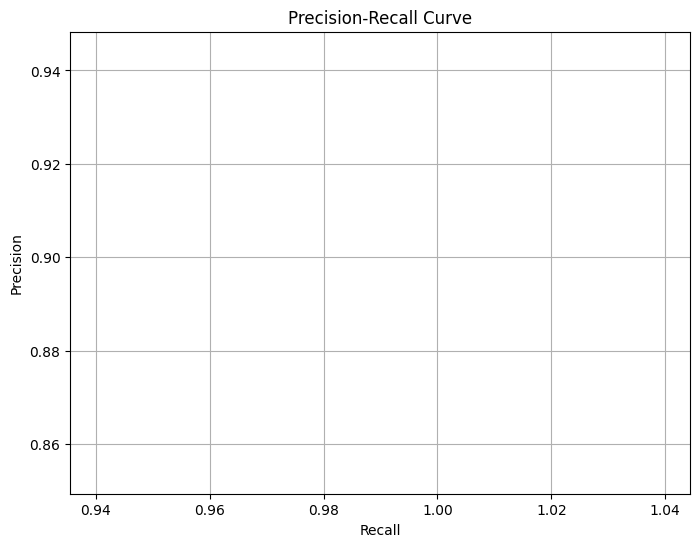

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid()

plt.show()

In [145]:
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_index])

Best threshold: 0.8624701534304415
Best F1: 0.9424502535591771


In [153]:
# target_recall = 0.95

# valid_indices = np.where(
#     recall[:-1] >= target_recall
# )[0]

# for i in valid_indices:
#     print(
#         f"Threshold={thresholds[i]:.4f}, "
#         f"Precision={precision[i]:.4f}, "
#         f"Recall={recall[i]:.4f}"
#     )

In [151]:
thresholds_to_test = np.arange(
    0.05,
    1.00,
    0.05
)

rows = []

for threshold in thresholds_to_test:

    y_pred = (
        y_val_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    precision_value = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall_value = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1_value = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    rows.append({
        "threshold": threshold,
        "precision": precision_value,
        "recall": recall_value,
        "f1": f1_value,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

threshold_df = pd.DataFrame(rows)

print(threshold_df)

    threshold  precision    recall        f1    TP    FP   FN      TN
0        0.05   0.880561  1.000000  0.936487  9739  1321    0  100287
1        0.10   0.880720  1.000000  0.936577  9739  1319    0  100289
2        0.15   0.880720  1.000000  0.936577  9739  1319    0  100289
3        0.20   0.880799  1.000000  0.936622  9739  1318    0  100290
4        0.25   0.880799  1.000000  0.936622  9739  1318    0  100290
5        0.30   0.880789  0.999897  0.936571  9738  1318    1  100290
6        0.35   0.880937  0.999795  0.936610  9737  1316    2  100292
7        0.40   0.881176  0.999795  0.936745  9737  1313    2  100295
8        0.45   0.881315  0.999589  0.936733  9735  1311    4  100297
9        0.50   0.881602  0.999281  0.936760  9732  1307    7  100301
10       0.55   0.882577  0.998665  0.937039  9726  1294   13  100314
11       0.60   0.883658  0.998254  0.937467  9722  1280   17  100328
12       0.65   0.885053  0.997741  0.938025  9717  1262   22  100346
13       0.70   0.88

In [152]:
print(
    threshold_df.to_string(
        index=False
    )
)

 threshold  precision   recall       f1   TP   FP  FN     TN
      0.05   0.880561 1.000000 0.936487 9739 1321   0 100287
      0.10   0.880720 1.000000 0.936577 9739 1319   0 100289
      0.15   0.880720 1.000000 0.936577 9739 1319   0 100289
      0.20   0.880799 1.000000 0.936622 9739 1318   0 100290
      0.25   0.880799 1.000000 0.936622 9739 1318   0 100290
      0.30   0.880789 0.999897 0.936571 9738 1318   1 100290
      0.35   0.880937 0.999795 0.936610 9737 1316   2 100292
      0.40   0.881176 0.999795 0.936745 9737 1313   2 100295
      0.45   0.881315 0.999589 0.936733 9735 1311   4 100297
      0.50   0.881602 0.999281 0.936760 9732 1307   7 100301
      0.55   0.882577 0.998665 0.937039 9726 1294  13 100314
      0.60   0.883658 0.998254 0.937467 9722 1280  17 100328
      0.65   0.885053 0.997741 0.938025 9717 1262  22 100346
      0.70   0.886343 0.996920 0.938385 9709 1245  30 100363
      0.75   0.889643 0.995790 0.939729 9698 1203  41 100405
      0.80   0.893397 0.

In [158]:
model_config = {
    "threshold": best_threshold,
    "features": X_train.columns.tolist()
}

joblib.dump(
    model_config,
    "model/model_config.pkl"
)

['model/model_config.pkl']

In [156]:
model_config = {
    "threshold": best_threshold,
    "features": X_train.columns.tolist()
}
model_config

{'threshold': np.float64(0.8624701534304415),
 'features': ['distance_from_home',
  'distance_from_last_transaction',
  'ratio_to_median_purchase_price',
  'repeat_retailer',
  'used_chip',
  'online_order']}